### 학습목표
- 딥러닝과 머신러닝의 차이점에 대해 알 수 있다.
- 딥러닝 모델 설계를 통하여 학습 및 평가를 할 수 있다.
- 딥러닝 모델 학습 중 회귀문제를 해결할 수 있다.

### 딥러닝이란?
- 인간의 신경망을 모방하여 학습하고 예측하는 기술
- 대량의 데이터에서 복잡한 패턴이나 규칙을 찾는 능력이 뛰어남
- 머신러닝에 비해 유연한 사고를 함 
- 인간의 뉴련 == 선형모델 (y=wx+b)
- 주로 음성처리, 영상처리, 자연어처리에 많이 이용
### 프레임워크
- tensorflow : 구글이 만든 딥러닝 라이브러리
- keras : tensorflow위에서 작동하는 사용자 친화적 라이브러리

### 머신러닝과 딥러닝의 차이점
- 머신러닝 
    - 모델생성(완성된 객체 사용) - 모델학습 - 모델예측 - 모델평가
- 딥러닝
    - 모델생성(모델을 직접 설계) - 모델학습 - 모델예측 - 모델평가


### 퍼셉트론 
- 딥러닝 모델을 구성하는 가장 작은 단위로, 선형결합 + 활성화함수 

- 공부시간에 따른 학생의 성적을 예측하는 회귀모델링
- 입력(X) : 공부시간 (studytime)
- 출력(y) : 성적 (G3) 

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 작업 디렉토리 설정 (본인 경로로 변경)
%cd /content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/Deep Learning
!pwd

/content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/Deep Learning
/content/drive/Othercomputers/LG DX 노트북/LG_Dx_School/Deep Learning


In [3]:
## library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [4]:
data = pd.read_csv("./data/student-mat.csv",sep=';')

In [5]:
data

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


In [6]:
X = data['studytime']
y = data['G3']

In [7]:
X.shape, y.shape

((395,), (395,))

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 30)

In [9]:
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(316,) (316,)
(79,) (79,)


In [10]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input,Dense
# Sequential : 모델의 뼈대생성
# Input : 입력층 설계도구
# Dense : 중간층, 출력층 설계 도구

#### 딥러닝 모델링 순서
1. 신경망 구조 설계
2. 학습방법 및 평가방법 설정 (회귀/분류)
3. 학습, 학습결과 시각화
4. 예측 및 평가

In [18]:
# 1. 신경망 구조 설계
# 뼈대생성
model = Sequential()
# 입력층
model.add(Input(shape=(1,))) # 입력특성의 형태를 입력 (1개의 입력특성, studytime)
# 중간층
model.add(Dense(units=10,activation='sigmoid')) # 한층에 사용할 뉴런의 개수 / 활성화 함수를 중간 층에 작성해줌. 
# 출력층
model.add(Dense(units = 1)) # 출력하고자 하는 데이터의 형태를 지정 -> 예측결과 -> 성적 ()

In [19]:
# 2. 학습방법 및 평가방법 설정 
model.compile(
    loss = 'mse',
    optimizer = 'SGD',
    metrics = ['mse']
)
# loss : 비용함수, 오차 -> 예측직선과 실제 값들의 차이
# optimizer : 최적화 함수 -> 오차를 수정해나가는 알고리즘
# metrics : 평가지표

In [20]:
#3. 학습 및 시각화
model.fit(X_train,y_train,epochs=20, validation_split=0.2)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 85.8654 - mse: 85.8654 - val_loss: 30.6262 - val_mse: 30.6262
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 29.8052 - mse: 29.8052 - val_loss: 20.7914 - val_mse: 20.7914
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 21.7142 - mse: 21.7142 - val_loss: 21.6902 - val_mse: 21.6902
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 21.0808 - mse: 21.0808 - val_loss: 22.1534 - val_mse: 22.1534
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 20.9930 - mse: 20.9930 - val_loss: 22.4490 - val_mse: 22.4490
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 20.9480 - mse: 20.9480 - val_loss: 22.5032 - val_mse: 22.5032
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 20.9731 - mse: 20.9731 - val_loss: 22.2423 - val_mse: 22.2423
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 21.0013 - mse: 21.0013 - val_loss: 22.4525 - val_mse: 22.4525
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

In [21]:
model.history.history

{'loss': [85.86536407470703,
  29.80518913269043,
  21.71419334411621,
  21.080791473388672,
  20.992990493774414,
  20.94799041748047,
  20.973098754882812,
  21.001256942749023,
  20.984386444091797,
  20.945375442504883,
  20.970489501953125,
  21.029296875,
  20.969823837280273,
  20.958051681518555,
  21.068449020385742,
  20.943809509277344,
  20.91645050048828,
  20.917949676513672,
  20.993221282958984,
  20.933998107910156],
 'mse': [85.86536407470703,
  29.80518913269043,
  21.71419334411621,
  21.080791473388672,
  20.992990493774414,
  20.94799041748047,
  20.973098754882812,
  21.001256942749023,
  20.984386444091797,
  20.945375442504883,
  20.970489501953125,
  21.029296875,
  20.969823837280273,
  20.958051681518555,
  21.068449020385742,
  20.943809509277344,
  20.91645050048828,
  20.917949676513672,
  20.993221282958984,
  20.933998107910156],
 'val_loss': [30.626232147216797,
  20.791439056396484,
  21.690195083618164,
  22.15340805053711,
  22.448997497558594,
  22

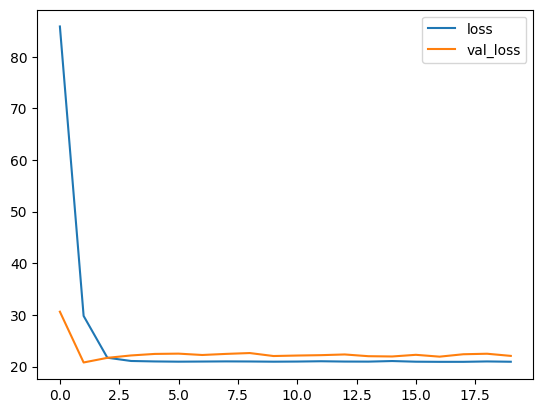

In [28]:
# 시각화
plt.plot(model.history.history['loss'],label = 'loss')
plt.plot(model.history.history['val_loss'],label = 'val_loss')
plt.legend()
plt.show()

In [29]:
# 평가
model.evaluate(X_test,y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 19.8534 - mse: 19.8534 


[19.85335350036621, 19.85335350036621]

##### 실습
- 입력특성을 4개 선택하여 모델 설계 후 핛브 및 시각화
- 성적을 예측하기 위하여 중요한 특성 4개를 선택

In [30]:
data

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


In [46]:
X2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   studytime  395 non-null    int64
 1   freetime   395 non-null    int64
 2   G1         395 non-null    int64
 3   G2         395 non-null    int64
dtypes: int64(4)
memory usage: 12.5 KB


In [196]:
X2 = data[['studytime','freetime','G1','G2']]
y = data['G3']

In [211]:
X2

,studytime,freetime,G1,G2
0,2,3,5,6
1,2,3,5,5
2,2,3,7,8
3,3,2,15,14
4,2,3,6,10
...,...,...,...,...
390,2,5,9,9
391,1,4,14,16
392,1,5,10,8
393,1,4,11,12


In [ ]:
X2_train,X2_test,y_train,y_test = train_test_split(X2,y,test_size=0.2,random_state =42)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. split
X2_train, X2_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)

# 2. scaler
scaler = StandardScaler()

# train만 fit
X2_train = scaler.fit_transform(X2_train)

# test는 transform만
X2_test = scaler.transform(X2_test)

In [213]:
print(X2_train.shape,y_train.shape)
print(X2_test.shape,y_test.shape)

(316, 4) (316,)
(79, 4) (79,)


In [240]:
model2 = Sequential()

# 입력층
model2.add(Input(shape=(4,))) # 입력특성의 형태를 입력 (4개의 입력특성, studytime)
# 중간층
model2.add(Dense(units=20,activation='relu')) # 한층에 사용할 뉴런의 개수 / 활성화 함수를 중간 층에 작성해줌. 
# model2.add(Dense(units=20)) # 한층에 사용할 뉴런의 개수 / 활성화 함수를 중간 층에 작성해줌. 
model2.add(Dense(units=30,activation='relu')) # 한층에 사용할 뉴런의 개수 / 활성화 함수를 중간 층에 작성해줌. 
model2.add(Dense(units=10,activation='relu')) # 한층에 사용할 뉴런의 개수 / 활성화 함수를 중간 층에 작성해줌. 
# 출력층
model2.add(Dense(units = 1)) # 출력하고자 하는 데이터의 형태를 지정 -> 예측결과 -> 성적 ()

In [241]:
# 2. 학습방법 및 평가방법 설정 
model2.compile(
    loss = 'mse',
    optimizer = 'Adam',
    metrics = ['mse']
)
# loss : 비용함수, 오차 -> 예측직선과 실제 값들의 차이
# optimizer : 최적화 함수 -> 오차를 수정해나가는 알고리즘
# metrics : 평가지표

In [242]:
#3. 학습 및 시각화
model2.fit(X2_train,y_train,epochs=100, validation_split=0.2)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 117.6279 - mse: 117.6279 - val_loss: 113.2885 - val_mse: 113.2885
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 111.1009 - mse: 111.1009 - val_loss: 106.0377 - val_mse: 106.0377
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 103.9052 - mse: 103.9052 - val_loss: 98.1783 - val_mse: 98.1783
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 95.8888 - mse: 95.8888 - val_loss: 89.5642 - val_mse: 89.5642
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 86.9490 - mse: 86.9490 - val_loss: 80.2918 - val_mse: 80.2918
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 77.5581 - mse: 77.5581 - val_loss: 70.3189 - val_mse: 70.3189
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 67.4207 - mse: 67.4207 - val_loss: 59.8675 - val_mse: 59.8675
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 56.8560 - mse: 56.8560 - val_loss: 49.4403 - val_mse: 49.4403
Epoch 9/100
8/8 ━━━━━━━━━━━━━━

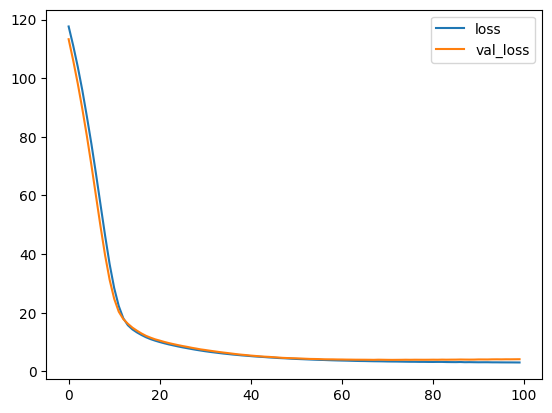

In [243]:
# 시각화
plt.plot(model2.history.history['loss'],label = 'loss')
plt.plot(model2.history.history['val_loss'],label = 'val_loss')
plt.legend()
plt.show()

In [244]:
# 평가
model2.evaluate(X2_test,y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.7062 - mse: 4.7062 


[4.7061920166015625, 4.7061920166015625]

In [256]:
X3 = data[['studytime','G1','G2','freetime']]
y = data['G3']

In [257]:
X3_train,X3_test,y_train,y_test = train_test_split(X3,y,test_size=0.2,random_state =42)

In [290]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. split
X3_train, X3_test, y_train, y_test = train_test_split(X3, y, test_size=0.2, random_state=42)

# 2. scaler
scaler = StandardScaler()

# train만 fit
X3_train = scaler.fit_transform(X3_train)

# test는 transform만
X3_test = scaler.transform(X3_test)

In [291]:
print(X3_train.shape,y_train.shape)
print(X2_test.shape,y_test.shape)

(316, 4) (316,)
(79, 4) (79,)


In [292]:
model3 = Sequential()

# 입력층
model3.add(Input(shape=(4,))) # 입력특성의 형태를 입력 (4개의 입력특성, studytime)
# 중간층
model3.add(Dense(units=10,activation='sigmoid')) # 한층에 사용할 뉴런의 개수 / 활성화 함수를 중간 층에 작성해줌. 
# model3.add(Dense(units=20,activation='sigmoid')) # 한층에 사용할 뉴런의 개수 / 활성화 함수를 중간 층에 작성해줌. 
# model3.add(Dense(units=20,activation='sigmoid')) # 한층에 사용할 뉴런의 개수 / 활성화 함수를 중간 층에 작성해줌. 
model3.add(Dense(units=20,activation='sigmoid')) # 한층에 사용할 뉴런의 개수 / 활성화 함수를 중간 층에 작성해줌. 
model3.add(Dense(units=10,activation='sigmoid')) # 한층에 사용할 뉴런의 개수 / 활성화 함수를 중간 층에 작성해줌. 
# 출력층
model3.add(Dense(units = 1)) # 출력하고자 하는 데이터의 형태를 지정 -> 예측결과 -> 성적 ()

In [293]:
# 2. 학습방법 및 평가방법 설정 
model3.compile(
    loss = 'mse',
    optimizer = 'SGD',
    metrics = ['mse']
)
# loss : 비용함수, 오차 -> 예측직선과 실제 값들의 차이
# optimizer : 최적화 함수 -> 오차를 수정해나가는 알고리즘
# metrics : 평가지표

In [294]:
#3. 학습 및 시각화
model3.fit(X3_train,y_train,epochs=100, validation_split=0.2)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 102.8411 - mse: 102.8411 - val_loss: 54.0282 - val_mse: 54.0282
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 40.7963 - mse: 40.7963 - val_loss: 23.6929 - val_mse: 23.6929
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 24.8958 - mse: 24.8958 - val_loss: 18.1092 - val_mse: 18.1092
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 22.4724 - mse: 22.4724 - val_loss: 17.3020 - val_mse: 17.3020
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 22.1462 - mse: 22.1462 - val_loss: 17.1587 - val_mse: 17.1587
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 22.2129 - mse: 22.2129 - val_loss: 17.0943 - val_mse: 17.0943
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 22.1538 - mse: 22.1538 - val_loss: 17.0974 - val_mse: 17.0974
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 22.0493 - mse: 22.0493 - val_loss: 17.0619 - val_mse: 17.0619
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0

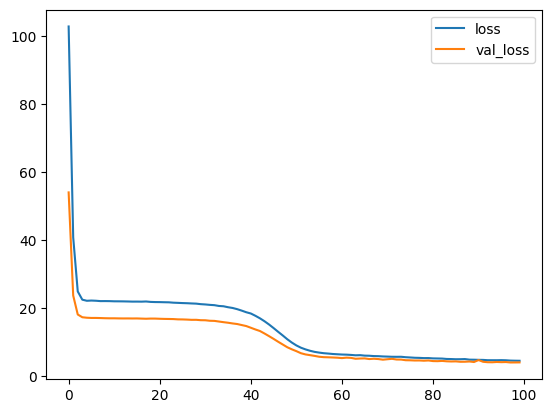

In [295]:
# 시각화
plt.plot(model3.history.history['loss'],label = 'loss')
plt.plot(model3.history.history['val_loss'],label = 'val_loss')
plt.legend()
plt.show()

In [296]:
# 평가
model3.evaluate(X3_test,y_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 4.5781 - mse: 4.5781 


[4.5781025886535645, 4.5781025886535645]

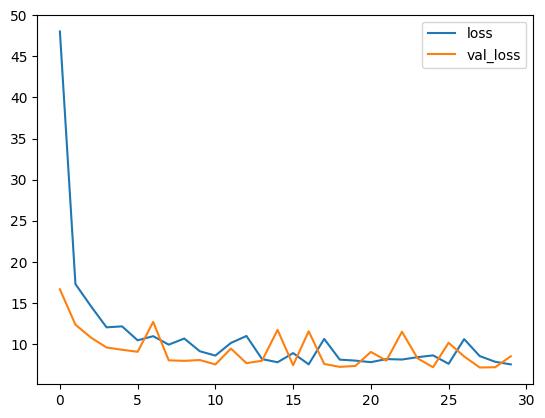

In [58]:
# 시각화
plt.plot(model.history.history['loss'],label = 'loss')
plt.plot(model.history.history['val_loss'],label = 'val_loss')
plt.legend()
plt.show()